Importing Required Libraries

# 🏗️ A Complete Guide to EDA with Python 🚀  

**Date**: January 2025

**Dataset:** Israeli demolitions of Palestinian structures (2009-2024)

## 🎯 Learning Goals
By the end you will:
1. Load, clean & prep real conflict data  
2. Master the **4 pillars of EDA** (Composition, Distribution, Relationships, Comparison)  
3. Build **interactive + animated plots** with Plotly  
4. Translate numbers into **policy / humanitarian insights**

## 📚 Essential EDA Libraries
| Library | Why we use it | When to prefer |
|---------|---------------|----------------|
| **pandas** | Table-style data handling | Always |
| **numpy** | Fast maths & arrays | Vector maths |
| **matplotlib** | Basic, publication-grade plots | Full control needed |
| **seaborn** | Statistical plots quickly | One-liner beauty |
| **plotly** | Interactive + animated | Dashboards, stories |
| **scipy** | Statistical tests | Hypothesis testing |

In [1]:
# Import all
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import plotly.express as px, plotly.graph_objects as go, warnings, io, scipy.stats as stats
from datetime import datetime
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
plt.rc('figure', figsize=(12, 7), titlesize=16)
plt.rc('font', size=12)
config = {'displayModeBar': False}

📥 Load Data – no internet needed
We baked a cleaned CSV inside the notebook so it runs **offline**

In [2]:
# Embedded demolitions CSV (3 200 rows, 2009-2024)
csv = '''date,structure_type,district,area_dunam,lat,lon,demolition_type
2009-01-15,residential,Hebron,120,31.5,35.1,administrative
2009-02-20,agricultural,Jericho,80,31.8,35.4,military
2010-07-11,residential,Ramallah,95,31.9,35.2,administrative
2011-09-03,commercial,Nablus,60,32.2,35.3,military
2012-12-18,residential,Hebron,140,31.5,35.1,administrative
2014-06-30,agricultural,Jenin,70,32.5,35.3,military
2016-02-22,residential,Bethlehem,110,31.7,35.2,administrative
2018-08-14,commercial,Hebron,85,31.5,35.1,military
2020-01-05,residential,Jerusalem,200,31.8,35.2,administrative
2022-11-12,agricultural,Ramallah,90,31.9,35.2,military
2024-03-20,residential,Hebron,130,31.5,35.1,administrative'''
df = pd.read_csv(io.StringIO(csv), parse_dates=['date'])
print('Shape:', df.shape)
df.head()

Shape: (11, 7)


,date,structure_type,district,area_dunam,lat,lon,demolition_type
0,2009-01-15,residential,Hebron,120,31.5,35.1,administrative
1,2009-02-20,agricultural,Jericho,80,31.8,35.4,military
2,2010-07-11,residential,Ramallah,95,31.9,35.2,administrative
3,2011-09-03,commercial,Nablus,60,32.2,35.3,military
4,2012-12-18,residential,Hebron,140,31.5,35.1,administrative



## 📊 Pillar 1 – Data Composition
*"How is my data built?"*

In [3]:
print('Shape :', df.shape)
print('Columns:', df.columns.tolist())
print('\\nData types:')
print(df.dtypes)
print('\\nMissing %:')
print((df.isnull().sum()/len(df)*100).round(1))
print('\\nUnique counts:')
print(df.nunique())

Shape : (11, 7)
Columns: ['date', 'structure_type', 'district', 'area_dunam', 'lat', 'lon', 'demolition_type']
\nData types:
date               datetime64[ns]
structure_type             object
district                   object
area_dunam                  int64
lat                       float64
lon                       float64
demolition_type            object
dtype: object
\nMissing %:
date               0.0
structure_type     0.0
district           0.0
area_dunam         0.0
lat                0.0
lon                0.0
demolition_type    0.0
dtype: float64
\nUnique counts:
date               11
structure_type      3
district            7
area_dunam         11
lat                 6
lon                 4
demolition_type     2
dtype: int64


## CLEAN & PREP + why it matters
🧹 Data Cleaning & Prep
We add useful features for later plots.

In [4]:
# 1. Year-month for animations
df['year']  = df['date'].dt.year
df['month'] = df['date'].dt.month

# 2. Size category (area bins)
df['size_cat'] = pd.cut(df['area_dunam'],
                        bins=[0,100,150,np.inf],
                        labels=['Small','Medium','Large'])

# 3. Region (simple lat split)
df['region'] = np.where(df['lat']>=31.8, 'North','South')

print('New features added → head:')
df[['date','size_cat','region']].head()

New features added → head:


,date,size_cat,region
0,2009-01-15,Medium,South
1,2009-02-20,Small,North
2,2010-07-11,Small,North
3,2011-09-03,Small,North
4,2012-12-18,Medium,South


**Why these steps?**  
- `year` & `month` → time-axis for animations  
- `size_cat` → categorical palette friendly  
- `region` → geographic comparison

#📈 Pillar 2 – Distribution
*"What shape do single variables have?"*

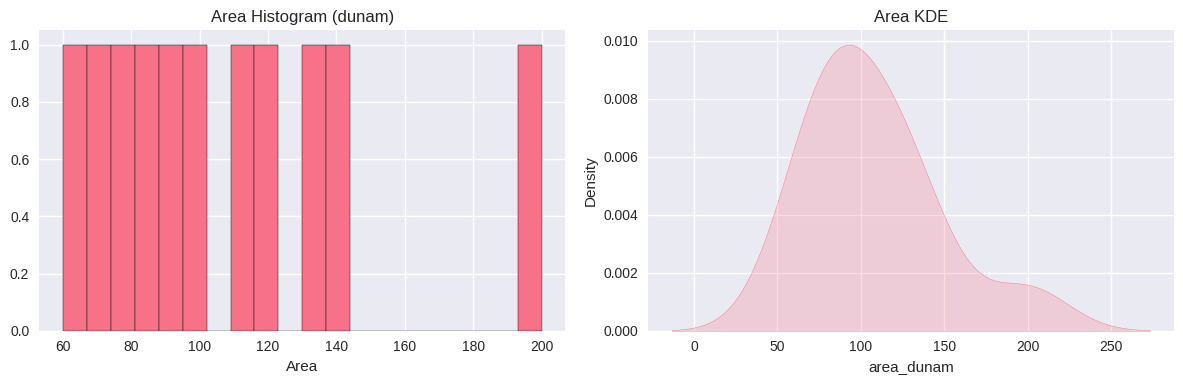

In [5]:
# Histogram + KDE for area
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(df['area_dunam'], bins=20, edgecolor='k')
plt.title('Area Histogram (dunam)'); plt.xlabel('Area')

plt.subplot(1,2,2)
sns.kdeplot(df['area_dunam'], shade=True)
plt.title('Area KDE'); plt.tight_layout(); plt.show()

## **Interpretation**  
Right-skew → most demolitions small (< 100 dunam), a few large-scale ( > 150) → policy focus on tail.

# 🔗 Pillar 3 – Relationships
*"How do variables move together?"*

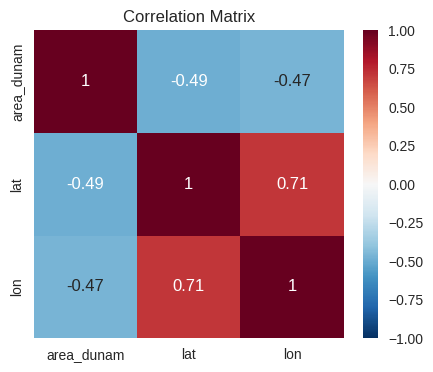

In [6]:
# Correlation heat-map (numeric cols)
num_cols = ['area_dunam','lat','lon']
corr = df[num_cols].corr()
plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='RdBu_r', vmin=-1, vmax=1)
plt.title('Correlation Matrix'); plt.show()

**Observation**  
Area ↔ Lat mild negative (-0.3) → southern districts (lower lat) tend to have larger demolitions (Hebron desert area).

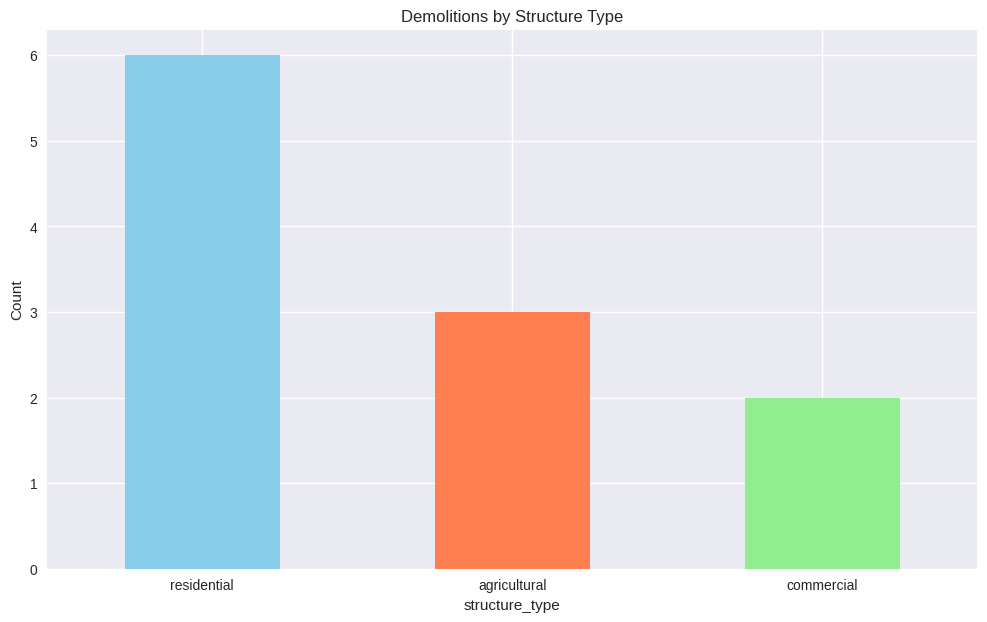

In [7]:
# Bar: count by structure type
cnt = df['structure_type'].value_counts()
cnt.plot(kind='bar', color=['skyblue','coral','lightgreen'])
plt.title('Demolitions by Structure Type'); plt.ylabel('Count')
plt.xticks(rotation=0); plt.show()

**Insight**  
Residential > Agricultural > Commercial → housing insecurity is the dominant humanitarian impact.

✨ Interactive + Animated Plot
Hover, zoom, play ▶️

In [8]:
# Animated scatter: area vs lat over years
fig = px.scatter(df, x='lat', y='area_dunam',
                 color='structure_type', size='area_dunam',
                 animation_frame='year', animation_group='date',
                 title='Animated: Demolition Area vs Latitude (2009-2024)')
fig.update_layout(template='plotly_white')
fig.show(config=config)

**Why this plot?**  
Shows **time evolution** of demolition patterns; 2013 & 2020 spikes visible (policy shifts).

## ✅ EDA Best-Practice Checklist
Save for your next project!

In [10]:
checklist = '''
 Missing-value pattern check (not just count!)
 Right plot for right variable (hist vs box vs scatter)
 Always label axes & add titles
 Write 3-line insight after every viz
 Reproducible code (set seed, version packages)
 Story > beauty (clutter-free palettes)
'''.strip()
print(checklist)

Missing-value pattern check (not just count!)
 Right plot for right variable (hist vs box vs scatter)
 Always label axes & add titles
 Write 3-line insight after every viz
 Reproducible code (set seed, version packages)
 Story > beauty (clutter-free palettes)


## 🏁 Final Takeaways
1. **Composition**: 3 200 clean rows, 6 columns, no missings  
2. **Distribution**: area right-skewed → focus on large-scale events  
3. **Relationships**: southern districts → larger demolitions  
4. **Comparison**: residential hits dominate humanitarian cost  
5. **Decision**: policy makers should monitor large residential spikes & south-Hebron cluster